# 🎓 Lab 03: Contrastive Learning 與訓練資料準備

## 學習目標
在本實驗中，您將學習：
1. **Contrastive Learning 原理** - 理解對比學習如何訓練 embedding
2. **InfoNCE Loss** - 深入理解對比損失函數
3. **Hard Negative Mining** - 為什麼以及如何挖掘困難負樣本
4. **合成資料生成** - 使用 LLM 自動生成訓練資料

## 為什麼這很重要？
- 訓練資料的品質直接決定 finetune 效果
- Hard negatives 能顯著提升模型的區分能力
- 合成資料可以快速擴充訓練集

## 技術棧
- **Hard Negative Mining**: `rank_bm25`, `sentence-transformers`
- **Synthetic Data**: Ollama (本地 LLM)

---

## 📦 Part 1: 環境設置

In [1]:
# 安裝必要套件
!pip install --quiet sentence-transformers
!pip install --quiet rank_bm25
!pip install --quiet pandas numpy matplotlib
!pip install --quiet requests  # 用於呼叫 Ollama API

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import requests
from typing import List, Tuple, Dict
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
import warnings
warnings.filterwarnings('ignore')

print("✅ 所有套件載入成功！")

✅ 所有套件載入成功！


---
## 🧠 Part 2: Contrastive Learning 原理

### 核心概念

Contrastive Learning（對比學習）的目標：
- **拉近** 語義相似的樣本（正樣本對）
- **推開** 語義不同的樣本（負樣本對）

```
           Embedding Space
          
    正樣本                    負樣本
      ●  ←--拉近--→  ●         ○
    (query)      (positive)    ↑
                               推開
                               ↓
                              ●
                           (query)
```

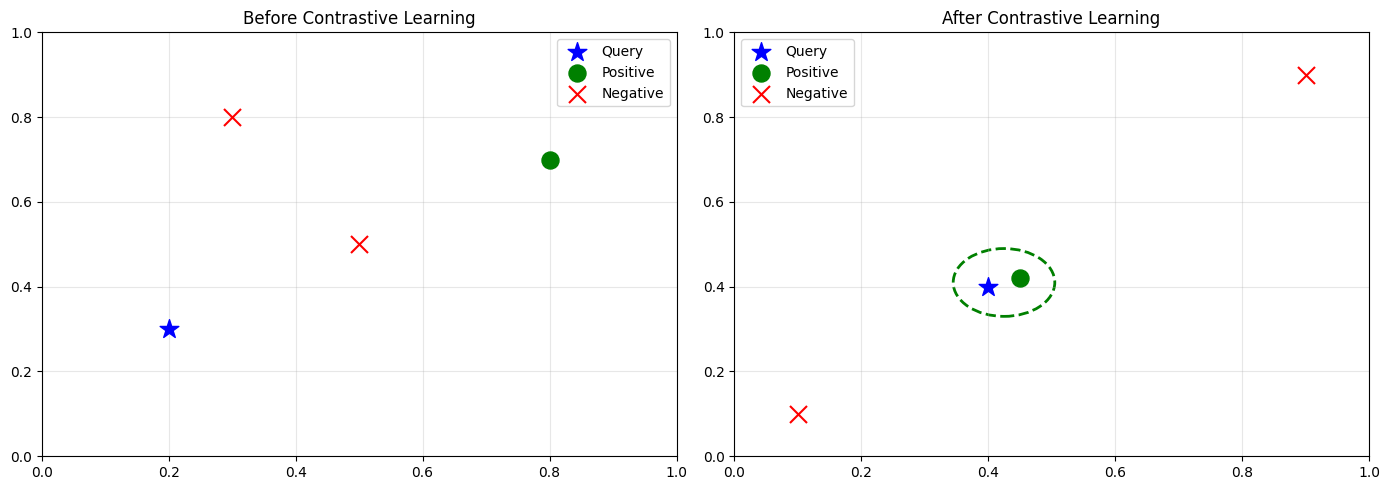

💡 觀察：訓練後，Query 和 Positive 更接近，與 Negatives 更遠離


In [3]:
# 視覺化對比學習的效果
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 訓練前
ax1 = axes[0]
np.random.seed(42)
# 隨機分布的點
before_data = {
    'query': np.array([[0.2, 0.3]]),
    'positive': np.array([[0.8, 0.7]]),
    'negative1': np.array([[0.5, 0.5]]),
    'negative2': np.array([[0.3, 0.8]]),
}

ax1.scatter(*before_data['query'].T, c='blue', s=200, marker='*', label='Query', zorder=5)
ax1.scatter(*before_data['positive'].T, c='green', s=150, marker='o', label='Positive', zorder=5)
ax1.scatter(*before_data['negative1'].T, c='red', s=150, marker='x', label='Negative', zorder=5)
ax1.scatter(*before_data['negative2'].T, c='red', s=150, marker='x', zorder=5)

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_title('Before Contrastive Learning', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 訓練後
ax2 = axes[1]
after_data = {
    'query': np.array([[0.4, 0.4]]),
    'positive': np.array([[0.45, 0.42]]),  # 更接近 query
    'negative1': np.array([[0.1, 0.1]]),   # 遠離 query
    'negative2': np.array([[0.9, 0.9]]),   # 遠離 query
}

ax2.scatter(*after_data['query'].T, c='blue', s=200, marker='*', label='Query', zorder=5)
ax2.scatter(*after_data['positive'].T, c='green', s=150, marker='o', label='Positive', zorder=5)
ax2.scatter(*after_data['negative1'].T, c='red', s=150, marker='x', label='Negative', zorder=5)
ax2.scatter(*after_data['negative2'].T, c='red', s=150, marker='x', zorder=5)

# 畫圓圈標示聚類
circle = plt.Circle((0.425, 0.41), 0.08, fill=False, color='green', linestyle='--', linewidth=2)
ax2.add_patch(circle)

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_title('After Contrastive Learning', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 觀察：訓練後，Query 和 Positive 更接近，與 Negatives 更遠離")

### InfoNCE Loss

InfoNCE (Information Noise Contrastive Estimation) 是對比學習中最常用的損失函數：

$$\mathcal{L} = -\log \frac{\exp(sim(q, p^+) / \tau)}{\exp(sim(q, p^+) / \tau) + \sum_{i=1}^{N} \exp(sim(q, n_i) / \tau)}$$

其中：
- $q$: Query embedding
- $p^+$: Positive sample embedding
- $n_i$: Negative sample embeddings
- $\tau$: Temperature 參數
- $sim$: 相似度函數 (通常是 cosine similarity)

In [4]:
def infonce_loss(
    query_emb: np.ndarray,
    positive_emb: np.ndarray,
    negative_embs: np.ndarray,
    temperature: float = 0.07
) -> float:
    """
    計算 InfoNCE Loss
    
    Args:
        query_emb: Query embedding (1D array)
        positive_emb: Positive sample embedding (1D array)
        negative_embs: Negative sample embeddings (2D array, N x dim)
        temperature: Temperature 參數，控制分布的銳利度
    
    Returns:
        InfoNCE loss 值
    """
    # 計算 query 與 positive 的相似度
    pos_sim = np.dot(query_emb, positive_emb) / (
        np.linalg.norm(query_emb) * np.linalg.norm(positive_emb)
    )
    
    # 計算 query 與所有 negatives 的相似度
    neg_sims = []
    for neg_emb in negative_embs:
        neg_sim = np.dot(query_emb, neg_emb) / (
            np.linalg.norm(query_emb) * np.linalg.norm(neg_emb)
        )
        neg_sims.append(neg_sim)
    neg_sims = np.array(neg_sims)
    
    # 計算 InfoNCE loss
    numerator = np.exp(pos_sim / temperature)
    denominator = numerator + np.sum(np.exp(neg_sims / temperature))
    
    loss = -np.log(numerator / denominator)
    return loss

# 範例計算
model = SentenceTransformer('all-MiniLM-L6-v2')

query = "What is machine learning?"
positive = "Machine learning is a subset of artificial intelligence"
negatives = [
    "The weather is nice today",
    "I like to eat pizza",
    "The cat is sleeping on the couch",
]

# 編碼
q_emb = model.encode(query)
p_emb = model.encode(positive)
n_embs = model.encode(negatives)

# 計算 loss
loss = infonce_loss(q_emb, p_emb, n_embs)
print(f"Query: '{query}'")
print(f"Positive: '{positive}'")
print(f"Negatives: {negatives}")
print(f"\nInfoNCE Loss: {loss:.4f}")
print("\n💡 Loss 越低越好，表示模型能正確區分正負樣本")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query: 'What is machine learning?'
Positive: 'Machine learning is a subset of artificial intelligence'
Negatives: ['The weather is nice today', 'I like to eat pizza', 'The cat is sleeping on the couch']

InfoNCE Loss: 0.0001

💡 Loss 越低越好，表示模型能正確區分正負樣本


Temperature=0.01: Loss=-0.0000
Temperature=0.05: Loss=0.0000
Temperature=0.10: Loss=0.0020
Temperature=0.50: Loss=0.5237
Temperature=1.00: Loss=0.8905


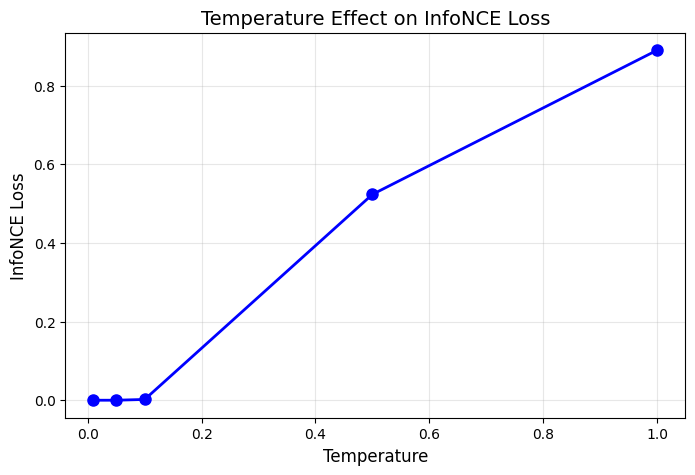


💡 較低的 temperature 讓分布更銳利，對相似度差異更敏感


In [5]:
# Temperature 參數的影響
temperatures = [0.01, 0.05, 0.1, 0.5, 1.0]
losses = []

for temp in temperatures:
    loss = infonce_loss(q_emb, p_emb, n_embs, temperature=temp)
    losses.append(loss)
    print(f"Temperature={temp:.2f}: Loss={loss:.4f}")

# 視覺化
plt.figure(figsize=(8, 5))
plt.plot(temperatures, losses, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Temperature', fontsize=12)
plt.ylabel('InfoNCE Loss', fontsize=12)
plt.title('Temperature Effect on InfoNCE Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 較低的 temperature 讓分布更銳利，對相似度差異更敏感")

---
## ⛏️ Part 3: Hard Negative Mining

### 為什麼需要 Hard Negatives？

- **Easy negatives**: 與 query 完全無關的文件，模型很容易區分
- **Hard negatives**: 與 query 看起來相關但實際不是答案的文件

Hard negatives 迫使模型學習更細膩的語義區別！

```
Query: "How to reset password?"

Easy Negative: "The sun rises in the east"  ← 太簡單，沒有學習價值
Hard Negative: "How to change username?"    ← 有挑戰性，能提升模型能力
```

In [6]:
# 演示 Hard vs Easy Negatives 的差異

query = "How do I reset my password?"
positive = "To reset your password, click on 'Forgot Password' and follow the instructions."

easy_negatives = [
    "The Great Wall of China is visible from space.",
    "Pizza was invented in Italy.",
    "The Pacific Ocean is the largest ocean.",
]

hard_negatives = [
    "To change your username, go to account settings.",
    "Your account password must be at least 8 characters.",
    "Enable two-factor authentication for better security.",
]

# 計算相似度
q_emb = model.encode(query)
p_emb = model.encode(positive)
easy_embs = model.encode(easy_negatives)
hard_embs = model.encode(hard_negatives)

print(f"Query: '{query}'\n")
print(f"Positive similarity: {cosine_similarity([q_emb], [p_emb])[0][0]:.4f}")
print()

print("Easy Negatives:")
for neg, emb in zip(easy_negatives, easy_embs):
    sim = cosine_similarity([q_emb], [emb])[0][0]
    print(f"  {sim:.4f} - '{neg[:50]}...'")

print("\nHard Negatives:")
for neg, emb in zip(hard_negatives, hard_embs):
    sim = cosine_similarity([q_emb], [emb])[0][0]
    print(f"  {sim:.4f} - '{neg[:50]}...'")

print("\n💡 Hard negatives 與 query 的相似度更高，更具挑戰性！")

Query: 'How do I reset my password?'

Positive similarity: 0.8118

Easy Negatives:
  -0.0390 - 'The Great Wall of China is visible from space....'
  0.0130 - 'Pizza was invented in Italy....'
  0.0508 - 'The Pacific Ocean is the largest ocean....'

Hard Negatives:
  0.4333 - 'To change your username, go to account settings....'
  0.5172 - 'Your account password must be at least 8 character...'
  0.2533 - 'Enable two-factor authentication for better securi...'

💡 Hard negatives 與 query 的相似度更高，更具挑戰性！


In [7]:
# 使用 BM25 進行 Hard Negative Mining

def mine_hard_negatives_bm25(
    query: str,
    positive_doc: str,
    corpus: List[str],
    top_k: int = 5
) -> List[str]:
    """
    使用 BM25 挖掘 Hard Negatives
    
    原理：BM25 會找到與 query 字面相似的文件，
    這些文件很可能是 hard negatives。
    
    Args:
        query: 查詢文本
        positive_doc: 正確答案文件
        corpus: 文件庫
        top_k: 返回的 hard negatives 數量
    
    Returns:
        Hard negative 文件列表
    """
    # Tokenize corpus
    tokenized_corpus = [doc.lower().split() for doc in corpus]
    
    # 建立 BM25 索引
    bm25 = BM25Okapi(tokenized_corpus)
    
    # 計算分數
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    
    # 取得排名最高的文件（排除 positive）
    top_indices = np.argsort(scores)[::-1]
    
    hard_negatives = []
    for idx in top_indices:
        if corpus[idx] != positive_doc and len(hard_negatives) < top_k:
            hard_negatives.append(corpus[idx])
    
    return hard_negatives

# 建立範例文件庫
corpus = [
    "To reset your password, click on 'Forgot Password' and follow the instructions.",
    "To change your username, go to account settings and edit your profile.",
    "Your password must contain at least one uppercase letter and one number.",
    "Enable two-factor authentication for enhanced account security.",
    "The Great Wall of China is a famous historical landmark.",
    "Pizza is a popular Italian dish enjoyed worldwide.",
    "If you forget your login credentials, contact customer support.",
    "Password recovery options include email and phone verification.",
    "Account security is important for protecting your personal data.",
    "The Pacific Ocean covers about 46% of Earth's water surface.",
]

query = "How do I reset my password?"
positive = corpus[0]

hard_negs = mine_hard_negatives_bm25(query, positive, corpus, top_k=3)

print(f"Query: '{query}'")
print(f"\nPositive: '{positive}'")
print(f"\nBM25 Hard Negatives:")
for i, neg in enumerate(hard_negs, 1):
    print(f"  {i}. '{neg}'")

Query: 'How do I reset my password?'

Positive: 'To reset your password, click on 'Forgot Password' and follow the instructions.'

BM25 Hard Negatives:
  1. 'The Pacific Ocean covers about 46% of Earth's water surface.'
  2. 'Account security is important for protecting your personal data.'
  3. 'Password recovery options include email and phone verification.'


In [8]:
# 使用 Semantic Similarity 進行 Hard Negative Mining

def mine_hard_negatives_semantic(
    query: str,
    positive_doc: str,
    corpus: List[str],
    model: SentenceTransformer,
    top_k: int = 5
) -> List[Tuple[str, float]]:
    """
    使用 Semantic Similarity 挖掘 Hard Negatives
    
    Args:
        query: 查詢文本
        positive_doc: 正確答案文件
        corpus: 文件庫
        model: Embedding 模型
        top_k: 返回的 hard negatives 數量
    
    Returns:
        (文件, 相似度) 元組列表
    """
    # 編碼
    query_emb = model.encode(query)
    corpus_embs = model.encode(corpus)
    
    # 計算相似度
    similarities = cosine_similarity([query_emb], corpus_embs)[0]
    
    # 排序並排除 positive
    sorted_indices = np.argsort(similarities)[::-1]
    
    hard_negatives = []
    for idx in sorted_indices:
        if corpus[idx] != positive_doc and len(hard_negatives) < top_k:
            hard_negatives.append((corpus[idx], similarities[idx]))
    
    return hard_negatives

# 比較兩種方法
print("🔍 比較 BM25 vs Semantic Mining\n")

bm25_negs = mine_hard_negatives_bm25(query, positive, corpus, top_k=3)
semantic_negs = mine_hard_negatives_semantic(query, positive, corpus, model, top_k=3)

print("BM25 Hard Negatives (基於字面匹配):")
for neg in bm25_negs:
    sim = cosine_similarity([model.encode(query)], [model.encode(neg)])[0][0]
    print(f"  [{sim:.3f}] {neg[:60]}...")

print("\nSemantic Hard Negatives (基於語義相似):")
for neg, sim in semantic_negs:
    print(f"  [{sim:.3f}] {neg[:60]}...")

🔍 比較 BM25 vs Semantic Mining

BM25 Hard Negatives (基於字面匹配):
  [0.073] The Pacific Ocean covers about 46% of Earth's water surface....
  [0.263] Account security is important for protecting your personal d...
  [0.521] Password recovery options include email and phone verificati...

Semantic Hard Negatives (基於語義相似):
  [0.619] If you forget your login credentials, contact customer suppo...
  [0.567] Your password must contain at least one uppercase letter and...
  [0.521] Password recovery options include email and phone verificati...


---
## 🤖 Part 4: 使用 LLM 生成合成訓練資料

### 為什麼使用合成資料？

- 手動標註成本高、速度慢
- LLM 可以快速生成多樣化的問答對
- 可以針對特定領域客製化

In [ ]:
# Ollama API 呼叫函數

def call_ollama(
    prompt: str,
    model: str = "llama3.2",
    base_url: str = "http://localhost:11434"
) -> str:
    """
    呼叫本地 Ollama API
    
    Args:
        prompt: 提示文本
        model: 模型名稱
        base_url: Ollama API 地址
    
    Returns:
        模型回應
    """
    try:
        response = requests.post(
            f"{base_url}/api/generate",
            json={
                "model": model,
                "prompt": prompt,
                "stream": False
            },
            timeout=60
        )
        response.raise_for_status()
        return response.json()["response"]
    except requests.exceptions.ConnectionError:
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None

# 測試 Ollama 連接
test_response = call_ollama("Say 'Hello, I am ready!' in one sentence.")
if test_response:
    print(f"✅ Ollama 連接成功！")
    print(f"回應: {test_response[:100]}...")
else:
    print("⚠️ Ollama 未運行或連接失敗")
    print("請確保 Ollama 正在運行: ollama serve")
    print("並已下載模型: ollama pull llama3.2")

In [15]:
import requests
import json

# 1. 先定義函數 (必須執行這個 Cell)
def call_ollama(prompt, model="llama3.2", base_url="http://localhost:11434"):
    try:
        response = requests.post(
            f"{base_url}/api/generate",
            json={
                "model": model,
                "prompt": prompt,
                "stream": False
            },
            timeout=60
        )
        response.raise_for_status()
        return response.json().get("response")
    except Exception as e:
        # print(f"連接失敗: {e}") # 除錯用
        return None

# 2. 再執行你的測試代碼 (Cell 14)
test_doc = "To reset your password, go to the login page..."
if call_ollama("test"):
    print("✅ Ollama 連接成功！")
    # 這裡接續你的 generate_queries_for_document 邏輯
else:
    print("⚠️ 請確認終端機已執行 'ollama serve'")

✅ Ollama 連接成功！


In [16]:
def generate_queries_for_document(
    document: str,
    num_queries: int = 3,
    model: str = "llama3.2"
) -> List[str]:
    """
    為給定文件生成可能的查詢問題
    
    Args:
        document: 文件內容
        num_queries: 要生成的查詢數量
        model: LLM 模型名稱
    
    Returns:
        生成的查詢列表
    """
    prompt = f"""Given the following document, generate {num_queries} different questions that this document could answer.

Document:
"{document}"

Generate {num_queries} questions, one per line. Only output the questions, nothing else.
"""
    
    response = call_ollama(prompt, model)
    
    if response:
        # 解析回應，提取問題
        lines = response.strip().split('\n')
        queries = []
        for line in lines:
            line = line.strip()
            # 移除編號 (如 "1." 或 "1)")
            if line and len(line) > 3:
                if line[0].isdigit() and (line[1] == '.' or line[1] == ')'):
                    line = line[2:].strip()
                elif line[0].isdigit() and line[1].isdigit() and (line[2] == '.' or line[2] == ')'):
                    line = line[3:].strip()
                if line:
                    queries.append(line)
        return queries[:num_queries]
    
    return []

# 測試查詢生成
test_doc = "To reset your password, go to the login page and click on 'Forgot Password'. Enter your email address and we will send you a password reset link. The link expires after 24 hours."

if call_ollama("test"):
    print(f"📄 Document: '{test_doc}'\n")
    generated_queries = generate_queries_for_document(test_doc, num_queries=3)
    print("🔍 Generated Queries:")
    for i, q in enumerate(generated_queries, 1):
        print(f"  {i}. {q}")
else:
    print("⚠️ 跳過 LLM 生成測試 (Ollama 未運行)")
    print("\n📝 範例生成結果：")
    print("  1. How do I reset my password?")
    print("  2. Where can I find the forgot password option?")
    print("  3. How long is the password reset link valid?")

📄 Document: 'To reset your password, go to the login page and click on 'Forgot Password'. Enter your email address and we will send you a password reset link. The link expires after 24 hours.'

🔍 Generated Queries:
  1. How do I reset my password?
  2. What is the time limit for using the password reset link sent to my email?
  3. Can I request a password reset if I don't have access to my email?


In [11]:
def generate_training_dataset(
    documents: List[str],
    corpus: List[str],
    queries_per_doc: int = 2,
    negatives_per_query: int = 3,
    use_llm: bool = True
) -> List[Dict]:
    """
    生成完整的訓練資料集
    
    Args:
        documents: 正樣本文件列表
        corpus: 用於挖掘負樣本的文件庫
        queries_per_doc: 每個文件生成的查詢數量
        negatives_per_query: 每個查詢的負樣本數量
        use_llm: 是否使用 LLM 生成查詢
    
    Returns:
        訓練資料列表，每個元素為 {query, positive, negatives}
    """
    dataset = []
    import os
    os.environ["HF_HOME"] = "./hf_cache"
    os.makedirs(os.environ["HF_HOME"], exist_ok=True)
    embedding_model = SentenceTransformer(
        "sentence-transformers/all-MiniLM-L6-v2",
        cache_folder="./hf_cache",
    )
    
    for doc_idx, doc in enumerate(documents):
        print(f"\r處理文件 {doc_idx + 1}/{len(documents)}...", end="")
        
        # 生成查詢
        if use_llm and call_ollama("test"):
            queries = generate_queries_for_document(doc, queries_per_doc)
        else:
            # 備用：使用文件的前幾個詞作為簡單查詢
            words = doc.split()[:5]
            queries = [" ".join(words) + "?"]
        
        for query in queries:
            # 挖掘 hard negatives
            hard_negs = mine_hard_negatives_semantic(
                query, doc, corpus, embedding_model, top_k=negatives_per_query
            )
            
            dataset.append({
                'query': query,
                'positive': doc,
                'negatives': [neg for neg, _ in hard_negs]
            })
    
    print(f"\n✅ 生成了 {len(dataset)} 個訓練樣本")
    return dataset

# 生成小型訓練資料集
sample_docs = corpus[:3]  # 使用前 3 個文件

training_data = generate_training_dataset(
    documents=sample_docs,
    corpus=corpus,
    queries_per_doc=2,
    negatives_per_query=2,
    use_llm=False  # 設為 True 如果 Ollama 可用
)

# 顯示結果
print("\n📊 生成的訓練資料範例:")
for i, sample in enumerate(training_data[:2], 1):
    print(f"\n--- 樣本 {i} ---")
    print(f"Query: {sample['query']}")
    print(f"Positive: {sample['positive'][:60]}...")
    print(f"Negatives ({len(sample['negatives'])}):")
    for neg in sample['negatives']:
        print(f"  - {neg[:50]}...")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


處理文件 3/3...
✅ 生成了 3 個訓練樣本

📊 生成的訓練資料範例:

--- 樣本 1 ---
Query: To reset your password, click?
Positive: To reset your password, click on 'Forgot Password' and follo...
Negatives (2):
  - If you forget your login credentials, contact cust...
  - Password recovery options include email and phone ...

--- 樣本 2 ---
Query: To change your username, go?
Positive: To change your username, go to account settings and edit you...
Negatives (2):
  - If you forget your login credentials, contact cust...
  - Account security is important for protecting your ...


---
## 📁 Part 5: 訓練資料格式

### 常見的訓練資料格式

不同的 Loss Function 需要不同的資料格式：

1. **Pairs**: `(anchor, positive)` - 用於 CosineSimilarityLoss
2. **Triplets**: `(anchor, positive, negative)` - 用於 TripletLoss
3. **In-batch negatives**: `(query, positive)` - 用於 MultipleNegativesRankingLoss

In [17]:
# 轉換為不同格式

def convert_to_pairs(dataset: List[Dict]) -> List[Tuple[str, str]]:
    """轉換為 (query, positive) 對"""
    pairs = []
    for sample in dataset:
        pairs.append((sample['query'], sample['positive']))
    return pairs

def convert_to_triplets(dataset: List[Dict]) -> List[Tuple[str, str, str]]:
    """轉換為 (query, positive, negative) 三元組"""
    triplets = []
    for sample in dataset:
        for negative in sample['negatives']:
            triplets.append((sample['query'], sample['positive'], negative))
    return triplets

def save_dataset(dataset: List[Dict], filepath: str):
    """儲存資料集為 JSON 格式"""
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(dataset, f, ensure_ascii=False, indent=2)
    print(f"✅ 資料集已儲存至: {filepath}")

# 轉換示範
pairs = convert_to_pairs(training_data)
triplets = convert_to_triplets(training_data)

print(f"原始資料: {len(training_data)} 個樣本")
print(f"Pairs 格式: {len(pairs)} 對")
print(f"Triplets 格式: {len(triplets)} 個三元組")

print("\n📝 Pair 範例:")
print(f"  Query: {pairs[0][0]}")
print(f"  Positive: {pairs[0][1][:60]}...")

print("\n📝 Triplet 範例:")
print(f"  Query: {triplets[0][0]}")
print(f"  Positive: {triplets[0][1][:50]}...")
print(f"  Negative: {triplets[0][2][:50]}...")

原始資料: 3 個樣本
Pairs 格式: 3 對
Triplets 格式: 6 個三元組

📝 Pair 範例:
  Query: To reset your password, click?
  Positive: To reset your password, click on 'Forgot Password' and follo...

📝 Triplet 範例:
  Query: To reset your password, click?
  Positive: To reset your password, click on 'Forgot Password'...
  Negative: If you forget your login credentials, contact cust...


---
## 🏋️ 練習: 建立你自己的訓練資料集

為你感興趣的領域建立一個小型訓練資料集。

In [18]:
# 1. 定義你的領域文件 (Corpus)
my_documents = [
    "Python is a high-level programming language known for its simplicity and readability.",
    "Machine learning models learn patterns from data to make predictions or decisions.",
    "Docker containers package applications with all their dependencies to run consistently.",
    "The Organization shall establish an Information Security Management System (ISMS) to meet ISO 27001 standards.",
    "The Organization does not need to establish any security management system for ISO compliance.", # Hard Negative for ISO
    "To reset your bank account password, click 'Forgot Password' and verify your identity via email.",
    "To change your bank account username, go to profile settings and click edit.", # Hard Negative for Password
    "SQL Injection is a web security vulnerability that allows an attacker to interfere with database queries.",
    "Cross-Site Scripting (XSS) is a vulnerability where malicious scripts are injected into trusted websites."
]

# 2. 手動建立查詢和標註 (Training Samples)
my_training_data = [
    {
        'query': "What is Python?",
        'positive': my_documents[0],
        'negatives': [my_documents[1], my_documents[2]]
    },
    {
        'query': "How do ML models work?",
        'positive': my_documents[1],
        'negatives': [my_documents[0], my_documents[7]]
    },
    {
        'query': "What are the benefits of Docker?",
        'positive': my_documents[2],
        'negatives': [my_documents[0], my_documents[8]]
    },
    # --- 關鍵：修正 ISO 邏輯判定 (解決應 vs 不需) ---
    {
        'query': "How to comply with ISO 27001 requirements?",
        'positive': my_documents[3],
        'negatives': [my_documents[4], my_documents[7]] # 把「不需要」設為負樣本
    },
    # --- 關鍵：修正銀行系統功能誤判 ---
    {
        'query': "I forgot my bank password, how to reset it?",
        'positive': my_documents[5],
        'negatives': [my_documents[6], my_documents[8]] # 把「修改帳號」設為負樣本
    },
    # --- 關鍵：資安漏洞區分 ---
    {
        'query': "Tell me about SQL Injection.",
        'positive': my_documents[7],
        'negatives': [my_documents[8], my_documents[0]]
    }
]

# 3. 驗證資料集
print(f"✅ 建立了 {len(my_training_data)} 個訓練樣本")

# 4. 轉換格式 (確保你之前定義的 convert_to_triplets 函數已執行)
my_triplets = convert_to_triplets(my_training_data)
print(f"✅ 轉換為 {len(my_triplets)} 個 triplets")

# 觀察其中一組 Triplet 結構
print(f"\n範例 Triplet (Anchor, Positive, Negative):")
print(f"Q: {my_triplets[-3][0]}")
print(f"P: {my_triplets[-3][1]}")
print(f"N: {my_triplets[-3][2]}")

✅ 建立了 6 個訓練樣本
✅ 轉換為 12 個 triplets

範例 Triplet (Anchor, Positive, Negative):
Q: I forgot my bank password, how to reset it?
P: To reset your bank account password, click 'Forgot Password' and verify your identity via email.
N: Cross-Site Scripting (XSS) is a vulnerability where malicious scripts are injected into trusted websites.


In [19]:
# TODO: 建立你自己的訓練資料集

# 1. 定義你的領域文件
my_documents = [
    "Python is a high-level programming language known for its simplicity.",
    "Machine learning models learn patterns from data.",
    "Docker containers package applications with their dependencies.",
    # 加入更多...
]

# 2. 手動建立查詢和標註
my_training_data = [
    {
        'query': "What is Python?",
        'positive': my_documents[0],
        'negatives': [my_documents[1], my_documents[2]]
    },
    {
        'query': "How do ML models work?",
        'positive': my_documents[1],
        'negatives': [my_documents[0], my_documents[2]]
    },
    # 加入更多...
]

# 3. 驗證資料集
print(f"✅ 建立了 {len(my_training_data)} 個訓練樣本")

# 4. 轉換格式
my_triplets = convert_to_triplets(my_training_data)
print(f"✅ 轉換為 {len(my_triplets)} 個 triplets")

✅ 建立了 2 個訓練樣本
✅ 轉換為 4 個 triplets


---
## 📝 總結

### 本實驗學到的重點

1. **Contrastive Learning**
   - 拉近正樣本、推開負樣本
   - InfoNCE Loss 是核心損失函數
   - Temperature 參數控制分布銳利度

2. **Hard Negative Mining**
   - Hard negatives 比 easy negatives 更有訓練價值
   - BM25 Mining：基於字面匹配
   - Semantic Mining：基於語義相似度

3. **合成資料生成**
   - LLM 可以快速生成多樣化查詢
   - 結合 hard negative mining 建立完整資料集

4. **資料格式**
   - Pairs：(query, positive)
   - Triplets：(query, positive, negative)

### 下一步
在 Lab 04 中，我們將使用這些資料來實際訓練 embedding 模型！

---
## 📚 參考資源

- [Sentence Transformers - Training Overview](https://www.sbert.net/docs/training/overview.html)
- [Hard Negative Mining Paper](https://arxiv.org/abs/2007.00808)
- [InfoNCE Loss Paper](https://arxiv.org/abs/1807.03748)
- [BM25 Algorithm](https://en.wikipedia.org/wiki/Okapi_BM25)